In [2]:
%reload_ext autoreload
%autoreload 2
# %matplotlib qt
%matplotlib inline

import random
import numpy as np
import torch
from matplotlib import pyplot as plt
from syd import make_viewer, Viewer
from tqdm import tqdm

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer
from vrAnalysis.helpers.plotting import format_spines, beeswarm, errorPlot, save_figure, add_scaled_limits
from vrAnalysis.processors.placefields import get_placefield
from dimilibi import PCA, SVCA
from dimensionality_manuscript.registry import PopulationRegistry, get_subspace, SubspaceName, RegistryPaths
from dimensionality_manuscript.subspace_analysis.base import Subspace
from dimensionality_manuscript.regression_models.hyperparameters import PlaceFieldHyperparameters
from dimensionality_manuscript.simulations import sqrtm_spd
from dimensionality_manuscript import SubspaceConfig, StimSpaceConfig, StimSpaceSpectraConfig, CVPCAConfig, TilburyFitConfig
from dimensionality_manuscript import ResultsAggregator, ResultsStore, get_data_config
from dimensionality_manuscript.scripts.status import status
from dimensionality_manuscript.subspace_analysis.stimspace import StimSpaceSubspace
from dimensionality_manuscript import average_by_mouse
plt.rcParams["font.size"] = 14

from dimensionality_manuscript.figure_scripts.figure3 import subspace_crossspace

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
registry = PopulationRegistry(registry_params=get_data_config("even").to_registry_params())
registry_paths = RegistryPaths()
figure_path = registry_paths.figure_path / "figure4"
if not figure_path.exists():
    figure_path.mkdir(parents=True, exist_ok=True)

In [3]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
store = ResultsStore()
cfg = StimSpaceSpectraConfig()
results = ResultsAggregator(cfg, store, sessions)

cfg_cvpca = CVPCAConfig()
results_cvpca = ResultsAggregator(cfg_cvpca, store, sessions)

cfg_fit = TilburyFitConfig()
results_fit = ResultsAggregator(cfg_fit, store, sessions)

cfg_subspace = SubspaceConfig()
results_subspace = ResultsAggregator(cfg_subspace, store, sessions)

In [4]:
from dimensionality_manuscript.figure_scripts.figure4 import placefield_spectra

return_syd_viewer = True
plt.close('all')
fig = placefield_spectra(
    results,
    results_cvpca=results_cvpca,
    ylim_min=-6.5,
    fontsize=9,
    figsize=(12, 4),
    activity_parameters_name="default",
    fit_range=(20, 30),
    smooth_widths=(5.0, None),
    smooth_kind="gaussian",
    smooth_width=3.0,
    reliability_fraction_active_thresholds=(None, None),
    include_iti=False,
    return_syd_viewer = return_syd_viewer,
)
if return_syd_viewer:
    fig.show()
else:
    plt.show()

    save = False
    if save:
        save_figure(fig, figure_path / "placefield_spectra")

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimilibi\helpers.py:431: RuntimeWarning: invalid value encountered in log
  return np.log(amplitude) - alpha * x
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure4.py:400: RuntimeWarning: Mean of empty slice
  ax[2].plot(xv, np.nanmean(la, axis=0), color=color, linewidth=2.0, label=k)


In [5]:
from dimensionality_manuscript.figure_scripts.figure4 import session_spectra

return_syd_viewer = True
plt.close('all')
fig = session_spectra(
    results,
    results_cvpca=results_cvpca,
    fit_range=(15, 30),
    ylim_min=-6.5,
    fontsize=9,
    figsize=(12, 4),
    activity_parameters_name="default",
    smooth_widths=(None, None),
    reliability_fraction_active_thresholds=(None, None),
    include_iti=False,
    return_syd_viewer = return_syd_viewer,
)
if return_syd_viewer:
    fig.show()
else:
    plt.show()

    save = False
    if save:
        save_figure(fig, figure_path / "placefield_spectra")

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimilibi\helpers.py:431: RuntimeWarning: invalid value encountered in log
  return np.log(amplitude) - alpha * x


In [ ]:
from dimensionality_manuscript.figure_scripts.figure4 import spectrum_figure

return_syd_viewer = True
plt.close('all')
fig = spectrum_figure(
    results,
    results_cvpca=results_cvpca,
    results_subspace=results_subspace,
    results_fit=results_fit,
    ylim_min=-5.5,
    fontsize=9,
    source_key = "ss_cvpca",
    activity_parameters_name="default",
    pf_fit_range=(20, 30),
    ff_fit_range=(50, 150),
    smooth_widths=(5.0, None),
    smooth_kind="gaussian",
    smooth_width=3.0,
    reliability_fraction_active_thresholds=(None, None),
    include_iti=False,
    normalize=False,
    figsize=(7.0, 3.0),
    return_syd_viewer = return_syd_viewer,
)
if return_syd_viewer:
    fig.show()
else:
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "placefield_spectra")

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimilibi\helpers.py:431: RuntimeWarning: invalid value encountered in log
  return np.log(amplitude) - alpha * x


In [39]:
from IPython.display import clear_output
from dimensionality_manuscript.figure_scripts.figure4 import placefield_example_fits

session_targets = {
    # "ATL012": ["2023-03-03"],
    # "ATL020": ["2023-03-31", "2023-04-04", "2023-04-05", "2023-04-06"],
    # "ATL022": ["2023-04-12", "2023-04-19"],     
    # "ATL027": ["2023-07-21"],
    # "ATL049": ["2024-04-30"],
    # "ATL057": ["2024-07-16", "2024-07-19"],
}

for isession, session in tqdm(enumerate(sessions)):
    if session.mouse_name not in session_targets:
        # print(f"Skipping session {session.session_uid} because mouse {session.mouse_name} is not in session_targets.")
        continue
    if session.date not in session_targets[session.mouse_name]:
        # print(f"Skipping session {session.session_uid} because date {session.date} is not in session_targets for mouse {session.mouse_name}.")
        continue

    return_syd_viewer = False
    plt.close('all')
    try: 
        fig = placefield_example_fits(
            results_fit,
            registry,
            example_session = session.session_uid,
            n_rows = 4,
            n_cols = 3,
            r2_threshold = 0.65,
            improvement_threshold = 0.01,
            random_seed=2,
            figsize = (12.0, 6.0),
            fontsize = 9.0,
            save_path=None,
            return_syd_viewer = return_syd_viewer,
        )
    except Exception as e:
        print(f"Error occurred while processing session {session.session_uid}: {e}")
    if return_syd_viewer:
        fig.show()
    else:
        fig.suptitle(f"Session {session.session_uid}", fontsize=12)
        plt.show()

        save = False
        if save:
            path_name = f"placefield_fits_{session.session_uid}"
            save_figure(fig, figure_path / "fit_examples" / path_name)


140it [00:00, ?it/s]


In [21]:
from dimensionality_manuscript.figure_scripts.figure4 import placefield_fit_figure

neuron_list = [
    ("ATL012.2023-03-03.701", 8466),
    ("ATL020.2023-04-04.701", 5383),
    ("ATL020.2023-04-04.701", 1384),
    ("ATL020.2023-04-04.701", 10117),
    ("ATL020.2023-04-05.701", 11023),
    ("ATL020.2023-04-05.701", 7568),
    ("ATL020.2023-04-06.701", 7454),
    ("ATL020.2023-04-06.701", 10461),
    ("ATL022.2023-04-12.701", 10112),
    ("ATL022.2023-04-12.701", 5637),
    ("ATL022.2023-04-19.701", 10238),
    ("ATL022.2023-04-19.701", 12708),
    ("ATL022.2023-04-19.701", 1154),
    ("ATL022.2023-04-19.701", 11196),
    ("ATL027.2023-07-21.701", 8140),
    ("ATL027.2023-07-21.701", 12449),
    ("ATL049.2024-04-30.701", 14001),
    ("ATL049.2024-04-30.701", 4420),
    ("ATL057.2024-07-16.701", 12789),
    ("ATL057.2024-07-16.701", 486),   
]

session_uids, neurons = zip(*neuron_list)

return_syd_viewer = True
plt.close('all')

fig = placefield_fit_figure(
    results_fit,
    registry,
    session_uids=session_uids,
    neurons=neurons,
    n_rows=5,
    n_cols=4,
    normalize="std",
    figsize=(12.0, 14.0),
    fontsize=9.0,
    save_path=None,
    return_syd_viewer=return_syd_viewer,
)
if return_syd_viewer:
    fig.show()
else:
    plt.show()

    save = False
    if save:
        save_figure(fig, figure_path / "placefield_fit_many_examples")



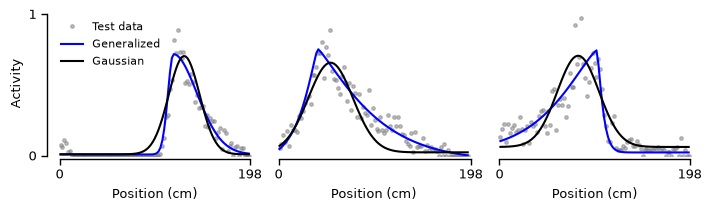

In [ ]:
from dimensionality_manuscript.figure_scripts.figure4 import placefield_fit_figure

best_neuron_list = [
    ("ATL049.2024-04-30.701", 4420),
    ("ATL012.2023-03-03.701", 8466),
    ("ATL020.2023-04-04.701", 5383),
    # ("ATL022.2023-04-19.701", 12708),
]

session_uids, neurons = zip(*best_neuron_list)

return_syd_viewer = False
plt.close('all')

fig = placefield_fit_figure(
    results_fit,
    registry,
    session_uids=session_uids,
    neurons=neurons,
    n_rows=1,
    n_cols=3,
    normalize="std",
    normalize_independent=True,
    figsize=(7.0, 2),
    fontsize=9.0,
    save_path=None,
    return_syd_viewer=return_syd_viewer,
)
if return_syd_viewer:
    fig.show()
else:
    plt.show()

    save = False
    if save:
        save_figure(fig, figure_path / "placefield_fit_best_examples")



C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)


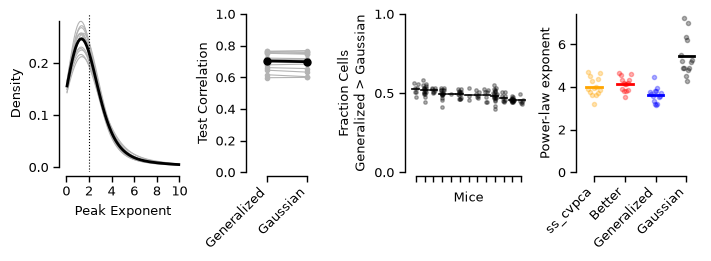

In [10]:
from dimensionality_manuscript.figure_scripts.figure4 import placefield_population

return_syd_viewer = False
plt.close('all')

fig = placefield_population(
    results_fit,
    results_spectra=results,
    results_cvpca=results_cvpca,
    source_key="ss_cvpca",
    num_bins = 80,
    fraction_view = "by_mouse",
    beewidth = 0.2,
    fontsize = 9.0,
    figsize = (7.0, 2.5),
    save_path=None,
    return_syd_viewer = return_syd_viewer,
    fit_range=(20, 30),
    smooth_kind="gaussian",
    smooth_width=3.0,
    smooth_widths=(5.0, None),
    reliability_fraction_active_thresholds=(0.3, 0.1),
)
if return_syd_viewer:
    fig.show()
else:
    plt.show()  

    save = True
    if save:
        save_figure(fig, figure_path / "placefield_fit_stats")


In [ ]:
# Checks to compare cvpca with config output and ss_cv and ss_orig etc etc

import numpy as np
import torch
from dimilibi import gaussian_filter
from dimilibi.cvpca import CVPCA
from dimilibi.helpers import vector_correlation
from vrAnalysis.helpers import edge2center, Timer
from vrAnalysis.database import get_database
from dimensionality_manuscript.configs.cvpca import CVPCAConfig
from dimensionality_manuscript.registry import PopulationRegistry

# get session database
sessiondb = get_database("vrSessions")
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR", session_params={"spks_type": "sigrebase"})
session = sessions[38]
print(session)

# get registry
registry = PopulationRegistry()


# --- get data: 3 unsmoothed folds (N, K) for the best env, exactly what cvpca uses ---
cfg = CVPCAConfig(reliability_fraction_active_thresholds=(None, None))
with Timer("process"):
    res, data = cfg.process(session, registry, return_data=True)   # <- your session, registry

pfs = data["torch_pfs"]                                          # list of 3, each (N, K)
K = pfs[0].shape[1]
centers = edge2center(data["dist_edges"]).astype(float)
if len(centers) != K:                 # bins were dropped; spacing is all the check needs
    centers = np.arange(K, dtype=float)
W = cfg.fixed_smooth_width

def smooth(pf):
    return gaussian_filter(pf, W, axis=1, stimulus_positions=centers, full_stimulus_positions=centers)

# --- estimators ---
def cvpca_like(c0s, c1, c2, axis):
    """axis=0 -> center over neurons (cvpca); axis=1 -> center over positions (_to_g style)."""
    cn = lambda x: x - x.mean(dim=axis, keepdim=True)
    _, _, Vt = torch.linalg.svd(cn(c0s), full_matrices=False)
    V = Vt.transpose(0, 1)
    p1 = cn(c1) @ V
    p2 = cn(c2) @ V
    return vector_correlation(p1, p2, covariance=True, dim=0, center=True)

def cvpca_ref(c0s, c1, c2):
    return CVPCA(center=True, on_stimuli=True).fit(c0s).score(c1, c2)

def ss_raw(c0s, c1, c2):
    """updated _to_g + single-fold SVD path: position-centered, uncentered neuron sum, 1/(K-1)."""
    g = lambda x: ((x - x.mean(1, keepdim=True)) / (x.shape[1] - 1) ** 0.5).numpy()
    g0, g1, g2 = g(c0s), g(c1), g(c2)
    U, _, Vt = np.linalg.svd(g0.T @ g0, full_matrices=False)     # basis from ONE fold
    return torch.from_numpy(np.sum(U * ((g1.T @ g2) @ Vt.T), axis=0))

def ss_orig(c0s, c1, c2):
    """original _to_g + single-fold SVD path: position-centered, uncentered neuron sum, 1/(K-1)."""
    g = lambda x: ((x - x.mean(1, keepdim=True)) / (x.shape[1] - 1) ** 0.5).numpy()
    g0, g1, g2 = g(c0s), g(c1), g(c2)
    U, _, Vt = np.linalg.svd(g0.T @ g2, full_matrices=False)
    return torch.from_numpy(np.sum(U * ((g1.T @ g2) @ Vt.T), axis=0))

# --- average over the 3 cyclic fold rotations, like cvpca ---
def spectrum(fn):
    terms = []
    for r in range(3):
        c0s = smooth(pfs[r])
        c1 = pfs[(r + 1) % 3]
        c2 = pfs[(r + 2) % 3]
        terms.append(torch.as_tensor(fn(c0s, c1, c2)))
    return torch.mean(torch.stack(terms), 0).numpy()

with Timer("ref_cfg"):
    ref_cfg = res["reg_covariances_fixed"]        # config output
with Timer("ref_mine"):
    ref_mine = spectrum(cvpca_ref)                 # CVPCA on the same data
with Timer("neuron"):
    neuron = spectrum(lambda a, b, c: cvpca_like(a, b, c, axis=0))
with Timer("position"):
    position = spectrum(lambda a, b, c: cvpca_like(a, b, c, axis=1))
with Timer("ssraw"):
    ssraw = spectrum(ss_raw)
with Timer("ssorig"):
    ssorig = spectrum(ss_orig)

def cmp(name, x, y):
    n = min(len(x), len(y)); x, y = x[:n], y[:n]
    r = np.corrcoef(x, y)[0, 1]
    ratio = np.median(y[np.abs(x) > 1e-9] / x[np.abs(x) > 1e-9])
    print(f"{name:34s} corr={r:+.4f}  median(y/x)={ratio:.4g}")

print("K =", K, " N =", pfs[0].shape[0])
cmp("cvpca_ref  vs  config output",  ref_mine, ref_cfg)   # ~1.0, ratio ~1  (validates re
cmp("neuron-cntr vs cvpca_ref",      neuron,   ref_mine)  # ~1.0, ratio ~1  (my estimator == cvpca)
cmp("position-cntr vs cvpca_ref",    position, ref_mine)  # << 1  (centering axis is the
cmp("ss_raw(_to_g) vs position-cntr",ssraw,    position)  # high corr, ratio ≈ (N-1)/(K-1)-ish            
cmp("ss_raw(_to_g) vs ss_orig(_to_g)", ssraw, ssorig)                                                                                                     

In [ ]:
from matplotlib import pyplot as plt

xv = lambda x: np.arange(len(x)) + 1
norm = lambda x: x / np.nansum(x)

plt.close('all')
plt.plot(xv(ref_cfg), norm(ref_cfg), label="ref_cfg")
plt.plot(xv(neuron), norm(neuron), label="neuron")
plt.plot(xv(position), norm(position), label="position")
plt.plot(xv(ssraw), norm(ssraw), label="ssraw")
plt.plot(xv(ssorig), norm(ssorig), label="ssorig")
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()